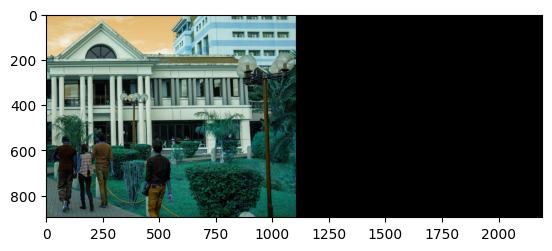

: 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from random import randrange

#Input image and then convert from RGB to Gray
# Resized Left Image e.g. 600 x 448
image1 = cv2.imread('assets/CafetariaLeft.jpg')
image1_gray = cv2.cvtColor(image1,cv2.COLOR_BGR2GRAY)
# Resized Right Image e.g. 600 x 448
image2 = cv2.imread('assets/CafetariaRight.jpg')
image2_gray = cv2.cvtColor(image2,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

#This step computes the sift keypoints and descriptors
keypoint1, descriptor1 = sift.detectAndCompute(image1_gray,None)
keypoint2, descriptor2 = sift.detectAndCompute(image2_gray,None)
cv2.imshow('orig_img_lft_keypnts',cv2.drawKeypoints(image1,keypoint1,None))
cv2.imwrite('orig_img_lft_keypnts.jpg',cv2.drawKeypoints(image1,keypoint1,None))
cv2.imshow('orig_img_rght_keypnts',cv2.drawKeypoints(image2,keypoint2,None))
cv2.imwrite('orig_img_rght_keypnts.jpg',cv2.drawKeypoints(image1,keypoint1,None))

#The FLANN method matches the features which are more similar. 
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=1000)
flann = cv2.FlannBasedMatcher(index_params,search_params)
matched_features = flann.knnMatch(descriptor1,descriptor2,k=2)

#This step filters through all the matches to obtain the best ones. 
ratio_pass = []
for f in matched_features:
	if f[0].distance < 0.25*f[1].distance:
		ratio_pass.append(f)
		matched_features = np.asarray(ratio_pass)

#This step will run RANSAC to estimate homography and performs image alignment.
if len(matched_features[:,0]) >= 2:
	init = np.float32([ keypoint1[f.queryIdx].pt for f in matched_features[:,0] ]).reshape(-1,1,2)
	goal = np.float32([ keypoint2[f.trainIdx].pt for f in matched_features[:,0] ]).reshape(-1,1,2)
	H, _ = cv2.findHomography(init, goal, cv2.RANSAC, 9.0)
else:
	print("Not able to find enough kpnts")

#This step performs the wrap to align for stitching.
final = cv2.warpPerspective(image1,H,(image2.shape[1] + image1.shape[1], image2.shape[0]))
plt.show()
plt.figure()
final[0:image2.shape[0], 0:image2.shape[1]] = image2
cv2.imwrite('Stitched_Image.jpg',final)
plt.imshow(final)
plt.show()

Left image keypoints: 3275
Right image keypoints: 2581
Good matches: 357


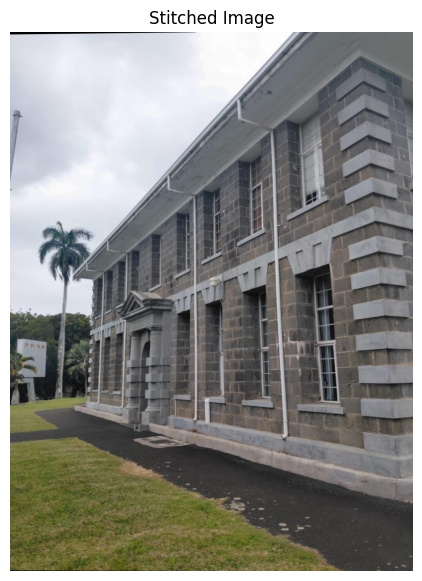

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load images
# ============================================================

# Left Image
image1 = cv2.imread('assets/buildLeft.jpeg')

# Right Image
image2 = cv2.imread('assets/buildRight.jpeg')

image1_gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
image2_gray = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)


# ============================================================
# SIFT Keypoints and Descriptors
# ============================================================

sift = cv2.SIFT_create()

keypoint1, descriptor1 = sift.detectAndCompute(image1_gray, None)
keypoint2, descriptor2 = sift.detectAndCompute(image2_gray, None)

print("Left image keypoints:", len(keypoint1))
print("Right image keypoints:", len(keypoint2))


# ============================================================
# FLANN Feature Matching
# ============================================================

FLANN_INDEX_KDTREE = 1

index_params = dict(
    algorithm=FLANN_INDEX_KDTREE,
    trees=5
)

search_params = dict(
    checks=100
)

flann = cv2.FlannBasedMatcher(
    index_params,
    search_params
)

matched_features = flann.knnMatch(
    descriptor1,
    descriptor2,
    k=2
)


# ============================================================
# Lowe's Ratio Test
# ============================================================

good_matches = []

for m, n in matched_features:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matches:", len(good_matches))


# ============================================================
# Calculate Homography
# ============================================================

if len(good_matches) >= 4:

    init = np.float32([
        keypoint1[m.queryIdx].pt
        for m in good_matches
    ]).reshape(-1, 1, 2)

    goal = np.float32([
        keypoint2[m.trainIdx].pt
        for m in good_matches
    ]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(
        init,
        goal,
        cv2.RANSAC,
        5.0
    )

    # ========================================================
    # Create larger canvas
    # ========================================================

    height1, width1 = image1.shape[:2]
    height2, width2 = image2.shape[:2]

    corners1 = np.float32([
        [0, 0],
        [width1, 0],
        [width1, height1],
        [0, height1]
    ]).reshape(-1, 1, 2)

    corners2 = np.float32([
        [0, 0],
        [width2, 0],
        [width2, height2],
        [0, height2]
    ]).reshape(-1, 1, 2)

    transformed_corners1 = cv2.perspectiveTransform(
        corners1,
        H
    )

    all_corners = np.concatenate(
        (transformed_corners1, corners2),
        axis=0
    )

    [xmin, ymin] = np.int32(
        all_corners.min(axis=0).ravel() - 0.5
    )

    [xmax, ymax] = np.int32(
        all_corners.max(axis=0).ravel() + 0.5
    )

    # ========================================================
    # Translation matrix
    # ========================================================

    translation = np.array([
        [1, 0, -xmin],
        [0, 1, -ymin],
        [0, 0, 1]
    ])

    # ========================================================
    # Warp the left image
    # ========================================================

    final = cv2.warpPerspective(
        image1,
        translation @ H,
        (xmax - xmin, ymax - ymin)
    )

    # ========================================================
    # Place the right image
    # ========================================================

    final[
        -ymin:height2 - ymin,
        -xmin:width2 - xmin
    ] = image2

    # ========================================================
    # Save and display
    # ========================================================

    cv2.imwrite(
        'Stitched_Image.jpg',
        final
    )

    plt.figure(figsize=(14, 7))
    plt.imshow(
        cv2.cvtColor(final, cv2.COLOR_BGR2RGB)
    )
    plt.title('Stitched Image')
    plt.axis('off')
    plt.show()

else:
    print("Not enough good matches to stitch the images.")